# ЛАБОРАТОРНА РОБОТА №7
## Методи інтерполювання зображень

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import cv2

### 1. Pеалізувати інтерполювання функції виду z = f(x, y) різними методами

In [ ]:
def func(x, y):
    return np.exp(-0.07*(x**2 + y**2)) * np.sin(x) * np.cos(y)

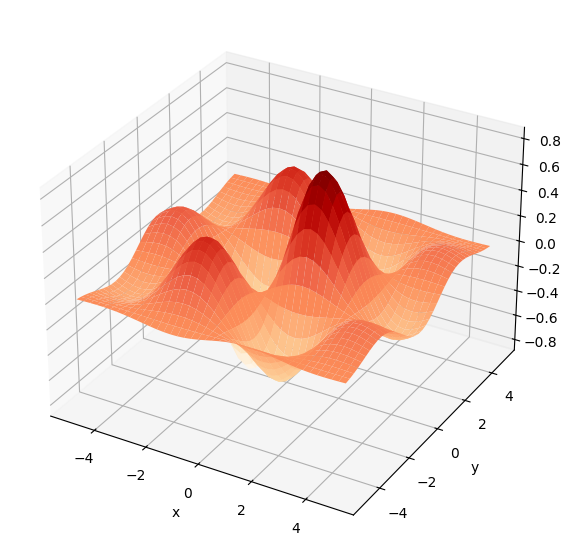

In [71]:
x = np.linspace(-5, 5, 40)
y = np.linspace(-5, 5, 40)
xx, yy = np.meshgrid(x, y)

z_values = func(xx, yy)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(xx, yy, z_values, cmap='OrRd')

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

### 1.1 Лінійне інтерполювання

In [57]:
def bilinear_interpolation(f_vals, X, Y, x_new, y_new):
    nx = len(X)
    ny = len(Y)
    f_interp = np.zeros((len(x_new), len(y_new)))

    for i in range(nx - 1):
        for j in range(ny - 1):
            for ix, x_val in enumerate(x_new):
                if X[i] <= x_val <= X[i+1]:
                    for jy, y_val in enumerate(y_new):
                        if Y[j] <= y_val <= Y[j+1]:
                            dx = X[i+1] - X[i]
                            dy = Y[j+1] - Y[j]

                            w00 = (X[i+1] - x_val) * (Y[j+1] - y_val)
                            w10 = (x_val - X[i]) * (Y[j+1] - y_val)
                            w01 = (X[i+1] - x_val) * (y_val - Y[j])
                            w11 = (x_val - X[i]) * (y_val - Y[j])

                            temp = (
                                f_vals[i, j] * w00 +
                                f_vals[i+1, j] * w10 +
                                f_vals[i, j+1] * w01 +
                                f_vals[i+1, j+1] * w11
                            ) / (dx * dy)

                            f_interp[ix, jy] = temp
    return f_interp

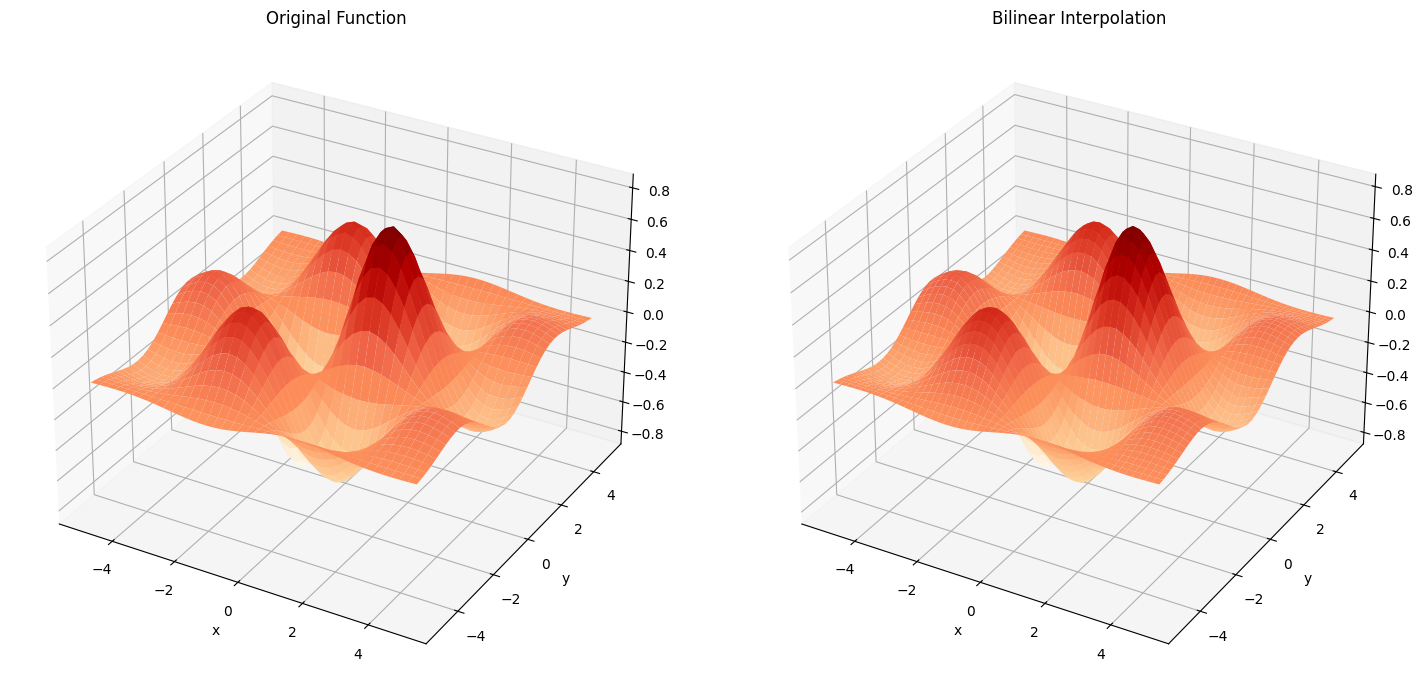

In [72]:
x_new = np.linspace(-5, 5, 50)
y_new = np.linspace(-5, 5, 50)
X_new, Y_new = np.meshgrid(x_new, y_new)

lin_interp = bilinear_interpolation(z_values, x, y, x_new, y_new)

fig = plt.figure(figsize=(15, 7))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(xx, yy, z_values, cmap='OrRd')
ax1.set_title('Original Function')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_new, Y_new, lin_interp, cmap= 'OrRd')
ax2.set_title('Bilinear Interpolation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

### 1.2 Інтерполювання з використанням методу найменших квадратів

In [ ]:
def least_squares_interpolution(x, y, z, degree_x, degree_y):
 
    A = []
    for xi, yi in zip(x, y):
        row = [xi**i * yi**j for i in range(degree_x + 1) for j in range(degree_y + 1)]
        A.append(row)
    A = np.array(A)

    b = np.array(z)
    coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    def interp_func(xi, yi):
        result = 0.0
        idx = 0
        for i in range(degree_x + 1):
            for j in range(degree_y + 1):
                result += coeffs[idx] * xi**i * yi**j
                idx += 1
        return result

    return interp_func

In [ ]:
x_flat = xx.flatten()
y_flat = yy.flatten()
z_flat = z_values.flatten()

degree = 3
func_ls_interp = least_squares_interpolution(x_flat, y_flat, z_flat, degree, degree)

leastsquares_interp = np.array([[func_ls_interp(xi, yi) for xi, yi in zip(row_x, row_y)]
                     for row_x, row_y in zip(xx, yy)])

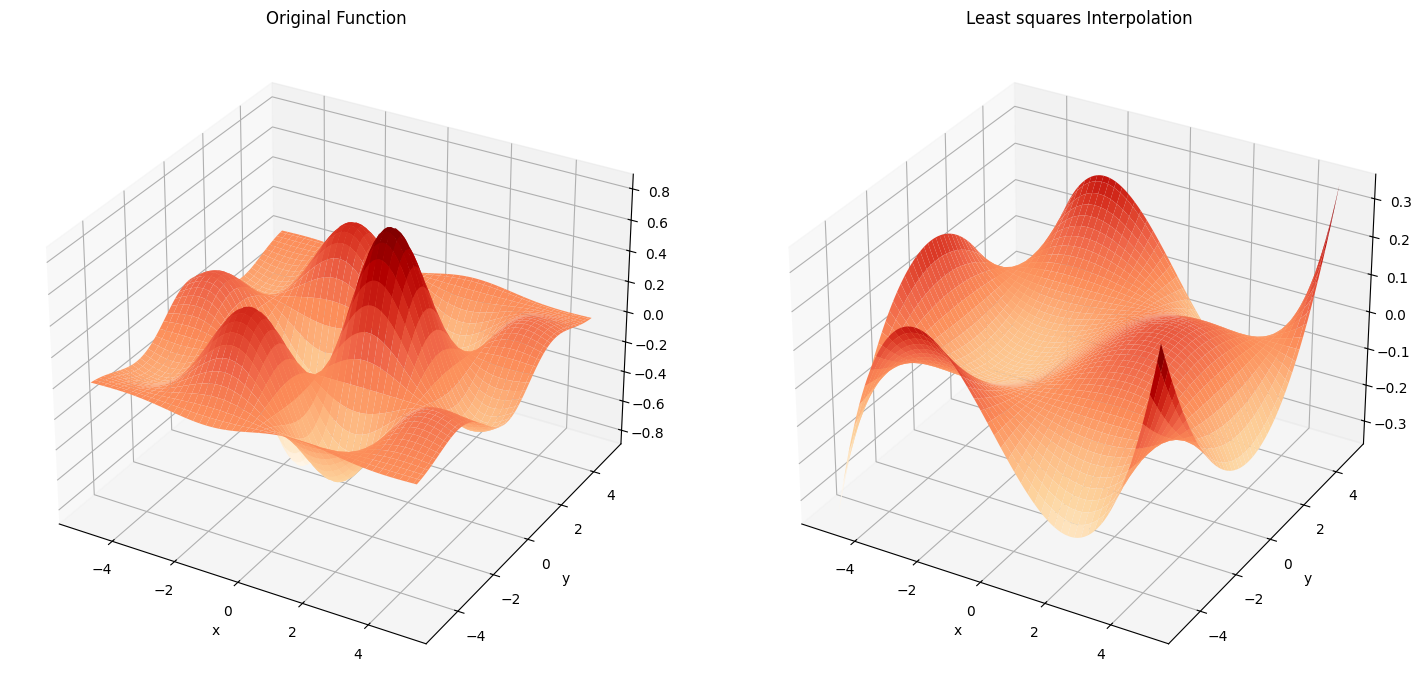

In [ ]:
fig = plt.figure(figsize=(15, 7))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(xx, yy, z_values, cmap='OrRd')
ax1.set_title('Original Function')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(xx, yy, leastsquares_interp, cmap= 'OrRd')
ax2.set_title('Least squares Interpolation')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

### 2. Програмно реалізувати інтерполювання зображення різними методами,

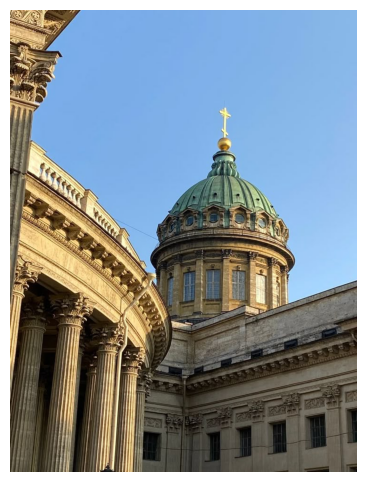

In [105]:
img_1 = cv2.imread('build.jpg')
img_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_1)
plt.axis("off")

plt.show()

### 2.1 Лінійне інтерполювання

In [ ]:
def bilinear_interpolate(image, new_height, new_width):

    old_height, old_width = image.shape[:2]
    if image.ndim == 3:
        channels = image.shape[2]
        resized = np.zeros((new_height, new_width, channels), dtype=image.dtype)
    else:
        channels = 1
        resized = np.zeros((new_height, new_width), dtype=image.dtype)

    scale_x = (old_width - 1) / (new_width - 1) if new_width > 1 else 0
    scale_y = (old_height - 1) / (new_height - 1) if new_height > 1 else 0

    for i in range(new_height):
        for j in range(new_width):
            x = scale_x * j
            y = scale_y * i

            x0 = int(np.floor(x))
            x1 = min(x0 + 1, old_width - 1)
            y0 = int(np.floor(y))
            y1 = min(y0 + 1, old_height - 1)

            dx = x - x0
            dy = y - y0

            if channels > 1:
                for c in range(channels):
                    top = (1 - dx) * image[y0, x0, c] + dx * image[y0, x1, c]
                    bottom = (1 - dx) * image[y1, x0, c] + dx * image[y1, x1, c]
                    resized[i, j, c] = (1 - dy) * top + dy * bottom
            else:
                top = (1 - dx) * image[y0, x0] + dx * image[y0, x1]
                bottom = (1 - dx) * image[y1, x0] + dx * image[y1, x1]
                resized[i, j] = (1 - dy) * top + dy * bottom

    return resized

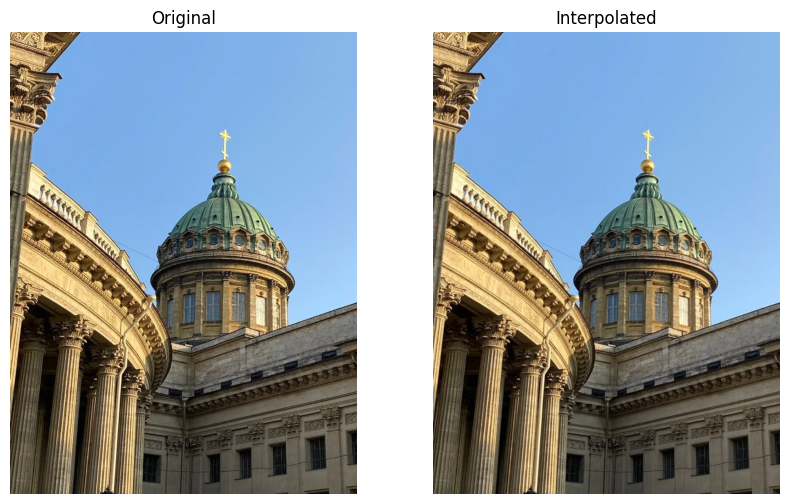

In [ ]:
img_np = np.array(img_1)
img_lin_interp = bilinear_interpolate(img_np, 1200, 900)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_1)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_lin_interp.astype(np.uint8))
plt.title("Interpolated")
plt.axis("off")

plt.show()